In [126]:
from collections import deque

def bfs(graph,start,goal):
    queue=deque([[start]])
    visited =set()
    while queue:
        path=queue.popleft()
        node=path[-1]
        if node==goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbour in graph[node]:
                queue.append(path+[neighbour])
    return None
                

In [170]:
def dfs(graph, start, goal):
    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        node = path[-1]


        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                stack.append(path + [neighbor])

    return None


In [172]:
maze = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E', 'G'],
    'G': []
}


print(bfs(maze, 'A', 'B'))


['A', 'B']


In [174]:

path=dfs(maze, 'A', 'G')

print("Path:", path)

Path: ['A', 'C', 'F', 'G']


Nodes: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Edges: [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F'), ('E', 'F'), ('F', 'G')]


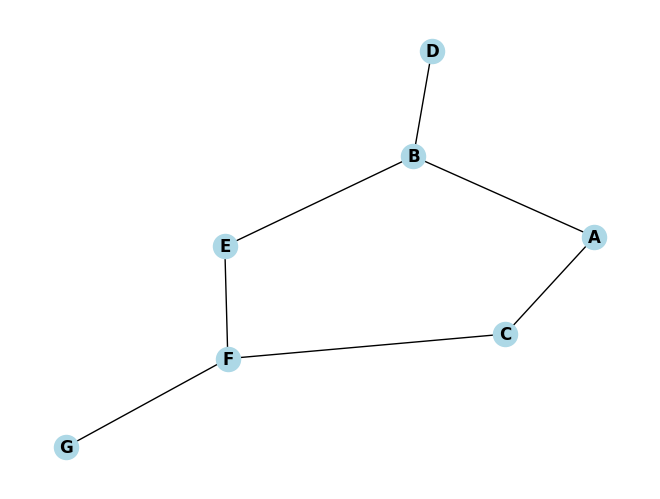

In [176]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph(maze)
print(f"Nodes: {G.nodes()}")
print(f"Edges: {G.edges()}")
nx.draw(G, with_labels=True, node_color='lightblue', font_weight='bold')


In [178]:
def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])


In [180]:
def get_neighbors(maze,node):
    x,y = node
    neighbour =[]
    for dx,dy in[(-1,0),(1,0),(0,-1),(0,1)]:
        nx,ny =x+dx,y+dy
        if (0<-nx<len(maze) and 0<=ny <len(maze[0]) and maze[nx][ny]==0):
            neighbors.append((nx,ny))
    return neighbors


In [69]:
def bfs_maze(maze,start,goal):
    queue=deque([[start]])
    visited= set()
    while queue:
        path= queue.popleft()
        node= path[-1]
        if node ==goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in get_neighbors(maze,node):
                queue.append(path+[neighbor])

In [87]:
def dfs_maze(maze,start,goal):
    stack=[[start]]
    visited=set()
    while stack:
        path= stack.pop()
        node=path[-1]
        if node== goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in get_neighbors(maze,node):
                stack.append(path+[neighbor])

In [89]:
import heapq
def heuristic(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])

In [91]:
def greedy_maze(maze,start,goal):
    frontier=[]
    heapq.heappush(frontier,(heuristic(start,goal),[start]))
    visited=set()
    while frontier:
        _, path= heapq.heappush(frontier)
        node=path[-1]
        if node== goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in get_neighbor(maze,node):
                priority= heurestic(neighbor,goal)
                heapq.heappush(frontier,(priority,path+n[neighbor]))

In [79]:
def astar_maze(maze,start,goal):
    frontier=[]
    heapq.heappush(frontier,(0,[start]))
    visited= set()
    while frontier:
        _, path=heapq.heappop(frontier)
        node= path[-1]
        if node== goal:
            return path
        if node not in visited :
            visited.add(node)
            for neighbor in get_neighbors(maze,node):
                g= len(path)
                h= heurestic(neighbor,goal)
                heapq.heappush(frontier,(g+h,path+n[neighbor]))

In [81]:
def rbfs_maze(maze,start,goal):
    stack = [[start]]
    visited = set()
    while stack:
        path = stack.pop()
        node = path[-1]
        if node == goal:
            return path
        if node not in visited:
            visited.add(node)
            neighbors = []
            for neighbor in get_neighbors(maze,node):
                if neighbor not in visited:
                    cost = len(path) + heuristic(neighbor,goal)
                    neighbors.append((cost,neighbor))
            neighbors.sort(reverse=True)
            for cost,neighbor in neighbors:
                stack.append(path+[neighbor])

In [ ]:
def sma_star_maze(maze,start,goal):
    frontier = []
    heapq.heappush(frontier,(0,[start]))
    visited = set()
    while frontier:
        cost,path = heapq.a(frontier)
        node = path[-1]
        if node == goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in get_neighbors(maze,node):
                new_cost = len(path) + heuristic(neighbor,goal)
                heapq.heappush(frontier,(new_cost,path+[neighbor]))

In [85]:
def ida_star_maze(maze,start,goal):
    threshold = heuristic(start,goal)
    def search(path,g,threshold):
        node = path[-1]
        f = g + heuristic(node,goal)
        if f > threshold:
            return f
        if node == goal:
            return path
        min_cost = float('inf')
        for neighbor in get_neighbors(maze,node):
            if neighbor not in path:
                result = search(path+[neighbor],g+1,threshold)
                if isinstance(result,list):
                    return result
                min_cost = min(min_cost,result)
        return min_cost
    path = [start]
    while True:
        result = search(path,0,threshold)
        if isinstance(result,list):
            return result
        threshold = result


In [111]:
def check_if_cyclic_using_your_dfs(graph):
    # We iterate through every node and its neighbors
    for u in graph:
        for v in graph[u]:
            # 1. Temporarily remove the edge (u, v)
            graph[u].remove(v)
            graph[v].remove(u)
            
            # 2. Try to find a path from u to v using YOUR function
            path = dfs_iterative(graph, u, v)
            
            # 3. Add the edge back (important for next checks!)
            graph[u].append(v)
            graph[v].append(u)
            
            # 4. If a path was found, we have a cycle!
            if path:
                print(f"Cycle found! Edge ({u}, {v}) completes the path: {path}")
                return True
                
    return False

# Your original function (unchanged)
def dfs_iterative(graph, start, goal):
    stack = [[start]]
    visited = set()
    while stack:
        path = stack.pop()
        node = path[-1]
        if node == goal:
            return path
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                if neighbor not in visited:
                    stack.append(path + [neighbor])
    return None

In [114]:
def dfs_all_paths_iterative(graph, start, goal):
    stack = [[start]]
    all_paths = []

    while stack:
        path = stack.pop()
        node = path[-1]

        if node == goal:
            all_paths.append(path)
            continue   # don't stop, keep finding more paths

        for neighbor in graph[node]:
            if neighbor not in path:   # prevents cycles in same path
                stack.append(path + [neighbor])

    return all_paths


In [116]:
def find_bridges(graph):
    bridges = []

    # We iterate through every node and its neighbors
    for u in graph:
        for v in graph[u]:

            # To avoid checking same edge twice (u,v) and (v,u)
            if (v, u) in bridges:
                continue

            # 1. Temporarily remove edge
            graph[u].remove(v)
            graph[v].remove(u)

            # 2. Check if u can still reach v
            path = dfs_iterative(graph, u, v)

            # 3. Add edge back
            graph[u].append(v)
            graph[v].append(u)

            # 4. If no path exists → bridge found
            if path is None:
                bridges.append((u, v))

    return bridges

def dfs_iterative(graph, start, goal):
    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                if neighbor not in visited:
                    stack.append(path + [neighbor])

    return None

graph = {
    'A': ['B'],
    'B': ['A', 'C', 'D'],
    'C': ['B', 'D'],
    'D': ['B', 'C', 'E'],
    'E': ['D']
}

print(find_bridges(graph))


[('A', 'B'), ('E', 'D')]


In [182]:
edges = [
    ('A','B'),
    ('A','C'),
    ('B','D'),
    ('C','D')
]


In [186]:
def make_adj_list(edges):
    graph = {}

    for u, v in edges:
        if u not in graph:
            graph[u] = []
        if v not in graph:
            graph[v] = []

        graph[u].append(v)
        graph[v].append(u)   # remove this line for directed graph

    return graph


edges = [('A','B'),('A','C'),('B','D'),('C','D')]

graph = make_adj_list(edges)

print(graph)


{'A': ['B', 'C'], 'B': ['A', 'D'], 'C': ['A', 'D'], 'D': ['B', 'C']}


In [188]:
# DFS function
def dfs(graph, start, visited):
    visited.add(start)
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited)


# Reverse graph
def reverse_graph(graph):
    rev = {}

    for node in graph:
        rev.setdefault(node, [])

    for u in graph:
        for v in graph[u]:
            rev[v].append(u)

    return rev


# Check strongly connected
def is_strongly_connected(graph):

    nodes = list(graph.keys())
    start = nodes[0]

    # Step 1: DFS on original graph
    visited = set()
    dfs(graph, start, visited)

    if len(visited) != len(graph):
        return False

    # Step 2: Reverse graph
    rev = reverse_graph(graph)

    # Step 3: DFS on reversed graph
    visited = set()
    dfs(rev, start, visited)

    if len(visited) != len(graph):
        return False

    return True


In [190]:
# Your DFS
def dfs(graph, start, visited):
    visited.add(start)
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited)


# Check articulation points
def find_articulation_points(graph):

    articulation_points = []

    for node in graph:

        # create graph copy without this node
        temp_graph = {}

        for u in graph:
            if u != node:
                temp_graph[u] = [v for v in graph[u] if v != node]

        # pick start node different from removed node
        start = None
        for n in temp_graph:
            start = n
            break

        visited = set()
        dfs(temp_graph, start, visited)

        # if some nodes not visited → articulation point
        if len(visited) != len(temp_graph):
            articulation_points.append(node)

    return articulation_points


In [192]:
def dfs(graph, node, visited):
    visited.add(node)
    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited)


def transitive_closure(graph):

    nodes = list(graph.keys())
    n = len(nodes)

    # create matrix filled with 0
    matrix = [[0]*n for _ in range(n)]

    for i in range(n):

        visited = set()
        dfs(graph, nodes[i], visited)

        for j in range(n):
            if nodes[j] in visited:
                matrix[i][j] = 1

    return matrix, nodes


In [194]:
from collections import deque

def bfs_distance(graph, start):

    queue = deque([(start, 0)])
    visited = {start}
    max_dist = 0

    while queue:
        node, dist = queue.popleft()

        max_dist = max(max_dist, dist)

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, dist+1))

    return max_dist


In [196]:
def diameter_and_radius(graph):

    eccentricities = {}

    for node in graph:
        eccentricities[node] = bfs_distance(graph, node)

    diameter = max(eccentricities.values())
    radius = min(eccentricities.values())

    return diameter, radius, eccentricities


In [198]:
graph = {
    'A': ['B'],
    'B': ['A','C','D'],
    'C': ['B'],
    'D': ['B','E'],
    'E': ['D']
}

diameter, radius, ecc = diameter_and_radius(graph)

print("Eccentricities:", ecc)
print("Diameter:", diameter)
print("Radius:", radius)


Eccentricities: {'A': 3, 'B': 2, 'C': 3, 'D': 2, 'E': 3}
Diameter: 3
Radius: 2
